<a href="https://colab.research.google.com/github/josevalladares99/Parcial4_JoseValladares-2524322022/blob/main/Notebooks/Parcial4_agrupacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


In [2]:
url="https://raw.githubusercontent.com/josevalladares99/Parcial4_JoseValladares-2524322022/refs/heads/main/Archivos%20CSV/clave_B_agrupacion.csv"

In [3]:
df=pd.read_csv(url)
df.head()


,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,B-R0196,35,962,3.08,42.02,4.95,6,1
1,B-R0031,18,534,3.36,47.80,6.81,2,14
2,B-R0059,24,408,2.24,68.25,5.75,0,1
3,B-R0204,48,1250,4.52,61.06,2.54,12,6
4,B-R0103,35,1043,6.96,78.62,7.37,0,1


In [15]:
# variables adecuadas para el clustering
features = ['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos', 'antiguedad_meses']
df_clustering = df[features]

# Manejar valores faltantes: eliminamos las filas que contengan NaN en las características seleccionadas
df_clustering = df_clustering.dropna()

# Mostramos las primeras filas del nuevo DataFrame para verificar
display(df_clustering.head())

,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,35,962,3.08,42.02,4.95,6,1
1,18,534,3.36,47.80,6.81,2,14
2,24,408,2.24,68.25,5.75,0,1
3,48,1250,4.52,61.06,2.54,12,6
4,35,1043,6.96,78.62,7.37,0,1


In [16]:
# Verificamos si aún hay valores NaN después de aplicar dropna()
print("Valores NaN en df_clustering después de dropna():")
display(df_clustering.isnull().sum())

Valores NaN en df_clustering después de dropna():


,0
edad,0
ingresos,0
frecuencia_uso,0
gasto_promedio,0
satisfaccion,0
reclamos,0
antiguedad_meses,0


In [13]:
from sklearn.preprocessing import StandardScaler

# Inicializamos el StandardScaler
scaler = StandardScaler()

# Aplicamos el escalador a nuestro DataFrame de clustering
df_scaled = scaler.fit_transform(df_clustering)

# Convertimos el array escalado de nuevo a un DataFrame para facilitar la visualización y manejo
df_scaled = pd.DataFrame(df_scaled, columns=df_clustering.columns)

# Mostrar las primeras filas del DataFrame escalado
display(df_scaled.head())

,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,-0.065229,0.040602,-0.759581,-0.768085,-1.044402,1.768927,-1.241479
1,-1.765053,-0.960135,-0.665920,-0.638191,-0.058939,-0.177519,-0.299957
2,-1.165115,-1.254744,-1.040564,-0.178619,-0.620547,-1.150742,-1.241479
3,1.234636,0.713995,-0.277896,-0.340199,-2.321264,4.688595,-0.879355
4,-0.065229,0.229994,0.538292,0.054426,0.237759,-1.150742,-1.241479


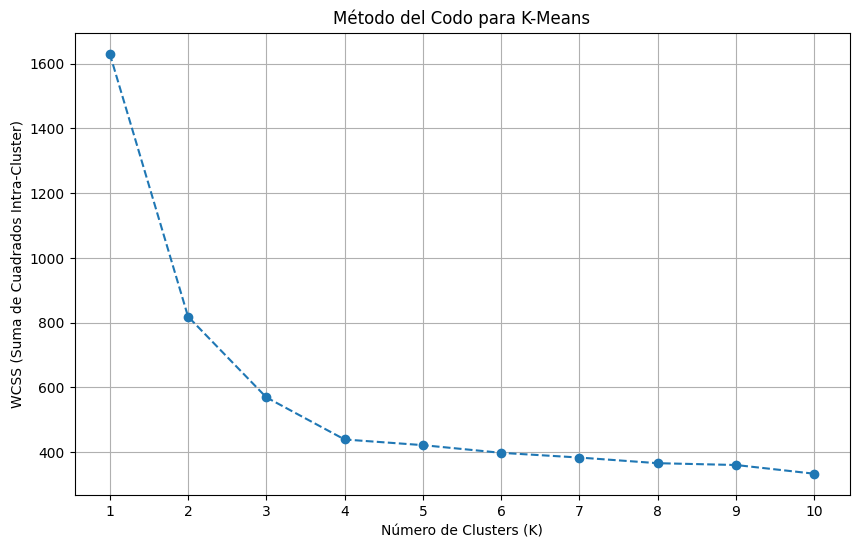

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Lista para almacenar los valores de WCSS
wcss = []

# Definimos el rango de clusters a probar (por ejemplo, de 1 a 10)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Graficamos el método del codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS (Suma de Cuadrados Intra-Cluster)')
plt.grid(True)
plt.xticks(range(1, 11))
plt.show()

### Aplicación del Algoritmo K-Means

Una vez que hemos determinado un número óptimo de clusters utilizando el método del codo (en este caso, seleccionaremos 4 clusters), procedemos a aplicar el algoritmo K-Means a nuestros datos escalados (`df_scaled`). K-Means agrupará los datos en `k` clusters, donde `k` es el número de clusters elegido, minimizando la inercia (suma de las distancias al cuadrado de las muestras a su centro de clúster más cercano).

In [17]:
from sklearn.cluster import KMeans

# Número óptimo de clusters seleccionado (por ejemplo, 4 basado en el método del codo)
n_clusters = 4

# Inicializamos y ajustamos el modelo K-Means a los datos escalados
kmeans_model = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
kmeans_model.fit(df_scaled)

# Obtenemos las etiquetas de los clusters para cada observación
cluster_labels = kmeans_model.labels_

# Añadimos las etiquetas de los clusters al DataFrame original (sin escalar, pero limpio de NaNs)
df_clustering['cluster'] = cluster_labels

# Mostramos las primeras filas del DataFrame con las nuevas etiquetas de cluster
display(df_clustering.head())

,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cluster
0,35,962,3.08,42.02,4.95,6,1,3
1,18,534,3.36,47.80,6.81,2,14,0
2,24,408,2.24,68.25,5.75,0,1,0
3,48,1250,4.52,61.06,2.54,12,6,3
4,35,1043,6.96,78.62,7.37,0,1,1


In [18]:
# Unimos el DataFrame original `df` con la columna de clusters del DataFrame `df_clustering`
# Usamos left_index=True y right_index=True para unir por el índice
# Usamos how='left' para mantener todas las filas del DataFrame original `df`.
# Las filas de `df` que no estaban en `df_clustering` (por los NaNs) tendrán `NaN` en la columna 'cluster'.
df = df.merge(df_clustering[['cluster']], left_index=True, right_index=True, how='left')

# Mostramos las primeras filas del DataFrame original con la nueva columna 'cluster'
display(df.head())

# Para verificar si hay valores NaN en la nueva columna 'cluster' (que corresponderían a las filas eliminadas por dropna)
print("\nConteo de valores NaN en la nueva columna 'cluster':")
print(df['cluster'].isnull().sum())

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,cluster
0,B-R0196,35,962,3.08,42.02,4.95,6,1,3.0
1,B-R0031,18,534,3.36,47.80,6.81,2,14,0.0
2,B-R0059,24,408,2.24,68.25,5.75,0,1,0.0
3,B-R0204,48,1250,4.52,61.06,2.54,12,6,3.0
4,B-R0103,35,1043,6.96,78.62,7.37,0,1,1.0



Conteo de valores NaN en la nueva columna 'cluster':
1


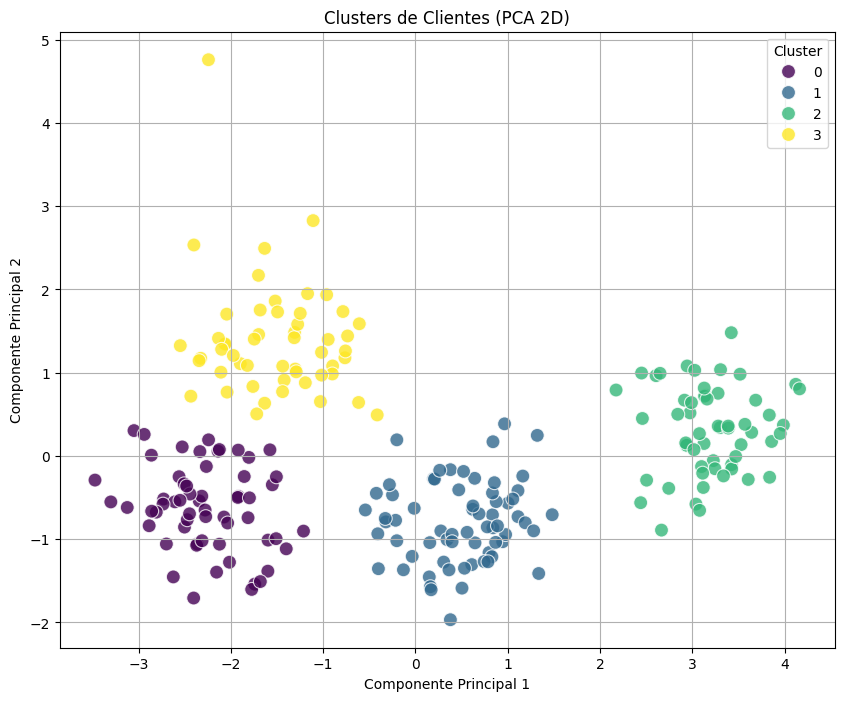

In [19]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Aplicamos PCA para reducir los datos a 2 componentes
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Creamos un DataFrame con los componentes PCA y las etiquetas de cluster
df_pca = pd.DataFrame(data=df_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = df_clustering['cluster'].values

# Visualizamos los clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_pca, palette='viridis', s=100, alpha=0.8)
plt.title('Clusters de Clientes (PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

In [20]:
# Agrupamos el DataFrame `df_clustering` (que contiene los clusters asignados) por la columna 'cluster'
# y calculamos la media de cada característica para obtener un resumen de cada grupo.
# df_clustering ya tiene la columna 'cluster' y está limpio de NaNs.
cluster_summary = df_clustering.groupby('cluster')[features].mean()

# Mostramos el resumen de los clusters
print("Resumen de las características por Cluster (medias):")
display(cluster_summary)

print("\n--- Sugerencia para la Interpretación de los Clusters ---\n")
print("**Instrucciones:** Analiza las medias de cada fila (cluster) para cada columna (característica). Compara estos valores entre los clusters para identificar patrones. Por ejemplo:")
print("  * **Cluster 0:** ¿Qué edad promedio tienen? ¿Sus ingresos son altos o bajos? ¿Cómo es su frecuencia de uso, gasto promedio, satisfacción, reclamos y antigüedad en comparación con otros clusters?")
print("  * **Cluster 1:** Repite el análisis para este cluster.")
print("  * **Cluster 2:** Repite el análisis para este cluster.")
print("  * **Cluster 3:** Repite el análisis para este cluster.")
print("\nUna vez identificados los patrones, puedes asignar un nombre descriptivo a cada cluster (por ejemplo, 'Clientes de Alto Valor', 'Clientes Recientes', 'Clientes Insatisfechos', etc.).")

Resumen de las características por Cluster (medias):


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
cluster,,,,,,,
0,24.220339,533.745763,1.965763,31.420847,5.951695,3.067797,6.932203
1,33.727273,896.409091,6.366818,81.448333,8.137727,1.106061,17.636364
2,47.500000,1572.714286,8.880714,137.553929,8.748036,0.625000,37.053571
3,38.307692,795.653846,4.100385,54.264038,4.510000,5.038462,11.134615



--- Sugerencia para la Interpretación de los Clusters ---

**Instrucciones:** Analiza las medias de cada fila (cluster) para cada columna (característica). Compara estos valores entre los clusters para identificar patrones. Por ejemplo:
  * **Cluster 0:** ¿Qué edad promedio tienen? ¿Sus ingresos son altos o bajos? ¿Cómo es su frecuencia de uso, gasto promedio, satisfacción, reclamos y antigüedad en comparación con otros clusters?
  * **Cluster 1:** Repite el análisis para este cluster.
  * **Cluster 2:** Repite el análisis para este cluster.
  * **Cluster 3:** Repite el análisis para este cluster.

Una vez identificados los patrones, puedes asignar un nombre descriptivo a cada cluster (por ejemplo, 'Clientes de Alto Valor', 'Clientes Recientes', 'Clientes Insatisfechos', etc.).
